In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('./data/loan.csv', sep = ',')

C:\Users\human3_01\AppData\Local\Temp\ipykernel_3020\3781110496.py:1: DtypeWarning: Columns (19,47,55,112,123,124,125,128,129,130,133,139,140,141) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./data/loan.csv', sep = ',')


In [4]:
df.head(10)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,5550,5550,5550.0,36 months,15.02,192.45,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,2000,2000,2000.0,36 months,17.97,72.28,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,6000,6000,6000.0,36 months,13.56,203.79,C,C1,...,NaN,NaN,DirectPay,N,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,6000,6000,6000.0,36 months,14.47,206.44,C,C2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.shape

(2260668, 145)

In [6]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_payoff_balance_amount', 'hardship_last_payment_amount',
       'disbursement_method', 'debt_settlement_flag',
       'debt_settlement_flag_date', 'settlement_status', 'settlement_date',
       'settlement_amount', 'settlement_percentage', 'settlement_term'],
      dtype='object', length=145)

In [7]:
df.tail(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
2260663,NaN,NaN,12000,12000,12000.0,60 months,14.08,279.72,C,C3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260664,NaN,NaN,12000,12000,12000.0,60 months,25.82,358.01,E,E4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260665,NaN,NaN,10000,10000,10000.0,36 months,11.99,332.10,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260666,NaN,NaN,12000,12000,12000.0,60 months,21.45,327.69,D,D5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260667,NaN,NaN,16550,16550,16550.0,60 months,21.45,451.94,D,D5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df2 = df[['loan_amnt', 'loan_status', 'grade', 'int_rate', 'term']]

In [9]:
df2.head(5)

,loan_amnt,loan_status,grade,int_rate,term
0,2500,Current,C,13.56,36 months
1,30000,Current,D,18.94,60 months
2,5000,Current,D,17.97,36 months
3,4000,Current,D,18.94,36 months
4,30000,Current,C,16.14,60 months


In [10]:
df2['loan_status'].unique()

array(['Current', 'Fully Paid', 'Late (31-120 days)', 'In Grace Period',
       'Charged Off', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [11]:
df2['grade'].unique()

array(['C', 'D', 'B', 'A', 'E', 'F', 'G'], dtype=object)

In [12]:
df2['term'].unique()

array([' 36 months', ' 60 months'], dtype=object)

In [13]:
df2.shape

(2260668, 5)

In [14]:
# nan 제거하기
# how = any --> nan이 있는 그 행은 모두 삭제 / how = all은 행 전체에 nan이 있는 경우에만 행 삭제
df2 = df2.dropna(how='any')
df2.shape

(2260668, 5)

## 30개월/60개월 두 가지 대출 상품을 운영

## 문제1) 36개월 대출과 60개월 대출의 대출 총액 계산
## 문제2) 각 대출 상태(불량/우량)에 따른 대출 등급 분포 파악
## 문제3) 대출 총액과 대출 이자율 간의 상관관계 파악
## 문제4) 결과를 csv 파일로 저장하기

## 문제1

In [118]:
terms = df2['term'].unique()

In [119]:
term30 = df2[df2['term'] == terms[0]]

In [120]:
amount30 = term30['loan_amnt'].sum()

In [121]:
term60 = df2[df2['term'] == terms[1]]

In [122]:
amount60 = term60['loan_amnt'].sum()

In [123]:
amount_result = pd.DataFrame({
    'total_loan_amnt': [amount30, amount60]
}, index=['36 months', '60 months'])
amount_result

,total_loan_amnt
36 months,20517162875
60 months,13498953050


## 문제2

In [124]:
df2.head(5)

,loan_amnt,loan_status,grade,int_rate,term
0,2500,Current,C,13.56,36 months
1,30000,Current,D,18.94,60 months
2,5000,Current,D,17.97,36 months
3,4000,Current,D,18.94,36 months
4,30000,Current,C,16.14,60 months


In [125]:
status = df2['loan_status'].unique()
status

array(['Current', 'Fully Paid', 'Late (31-120 days)', 'In Grace Period',
       'Charged Off', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [126]:
good = df2[(df2['loan_status'] == status[0]) | (df2['loan_status'] == status[1]) | (df2['loan_status'] == status[7])]
bad = df2[(df2['loan_status'] != status[0]) & (df2['loan_status'] != status[1]) & (df2['loan_status'] != status[7])]

In [127]:
good_grade = good['grade'].value_counts()
bad_grade = bad['grade'].value_counts()

In [128]:
grade_result = pd.DataFrame({'good':good_grade, 'bad':bad_grade})
grade_result

,good,bad
grade,,
A,417002,16025
B,604799,58758
C,554473,95580
D,256999,67425
E,96758,38881
F,26380,15420
G,7224,4944


## 문제3

In [129]:
df2['loan_amnt'].corr(df2['int_rate'])

np.float64(0.09808333533023365)

## 문제4

In [130]:
grade_result.to_csv('./data/loan_grade.csv', index=True)

In [131]:
amount_result.to_csv('./data/loan_amount.csv', index=True)

In [132]:
%matplotlib inline

<Axes: title={'center': 'good or bad grade'}, xlabel='grade'>

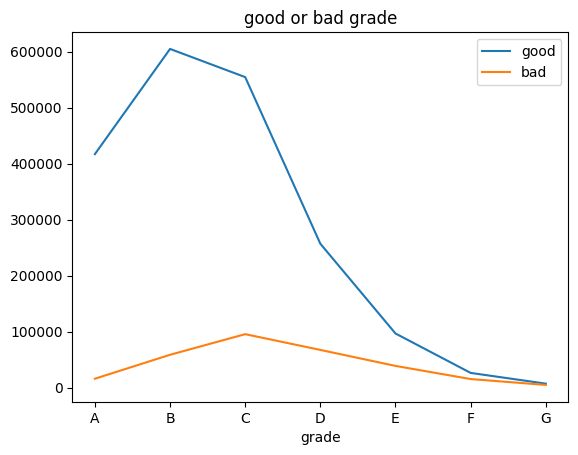

In [133]:
grade_result.plot(title='good or bad grade')

<Axes: title={'center': 'total_amount by term'}>

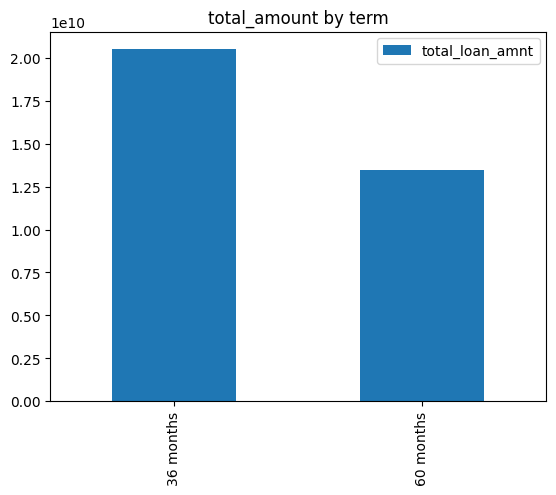

In [134]:
amount_result.plot(kind='bar', title='total_amount by term')

## 강사님 문제 풀이

## 문제1

In [135]:
# 결과를 저장할 딕셔너리 생성
term_to_loan_amnt_dict = {}
# term 컬럼의 고유값 추출
uniq_terms = df2['term'].unique()

In [136]:
# 각 대출기간(term)에 대해 반복 계산
# 해당 행들의 loan_amnt(대출금액) 컬럼 합계 계산
for term in uniq_terms:
    # df2['term'] 값이 uniq_term과 같으면, loan_amnt의 열을 갖고와서 sum을 수행
    loan_amnt_sum = df2.loc[df2['term'] == term, 'loan_amnt'].sum()
    # 계산된 합계를 딕셔너리에 저장
    term_to_loan_amnt_dict[term] = loan_amnt_sum

In [137]:
term_to_loan_amnt_dict

{' 36 months': np.int64(20517162875), ' 60 months': np.int64(13498953050)}

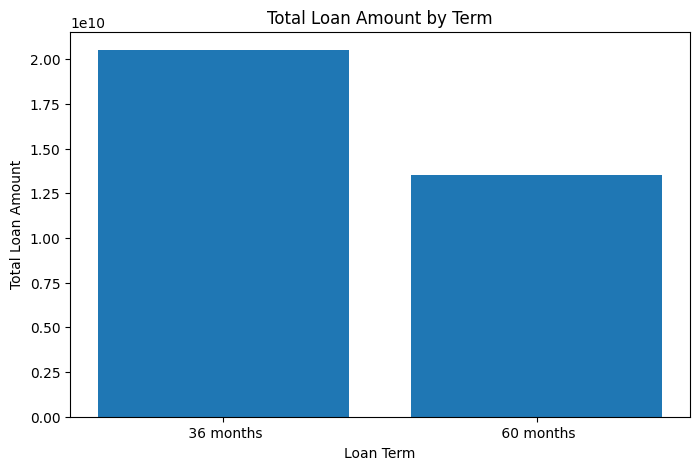

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(
    term_to_loan_amnt_dict.keys(),
    term_to_loan_amnt_dict.values()
)

plt.title('Total Loan Amount by Term')
plt.xlabel('Loan Term')
plt.ylabel('Total Loan Amount')

plt.show()

## 문제2

In [139]:
df2.head()

,loan_amnt,loan_status,grade,int_rate,term
0,2500,Current,C,13.56,36 months
1,30000,Current,D,18.94,60 months
2,5000,Current,D,17.97,36 months
3,4000,Current,D,18.94,36 months
4,30000,Current,C,16.14,60 months


In [140]:
df2['loan_status'].unique()

array(['Current', 'Fully Paid', 'Late (31-120 days)', 'In Grace Period',
       'Charged Off', 'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [143]:
# loan_status 고유값 추출
total_status_category = df2['loan_status'].unique()

# 불량 등급만 모으기 (인덱스로 정의)
bad_status_category = total_status_category[[2,3,4,5,6,8]]

In [144]:
bad_status_category

array(['Late (31-120 days)', 'In Grace Period', 'Charged Off',
       'Late (16-30 days)', 'Default',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

In [146]:
# loan_status가 bad_loan_status에 속하면 true, 아니면 false
df2['bad_loan_status'] = df2['loan_status'].isin(bad_status_category)
df2.head()

,loan_amnt,loan_status,grade,int_rate,term,bad_loan_status
0,2500,Current,C,13.56,36 months,False
1,30000,Current,D,18.94,60 months,False
2,5000,Current,D,17.97,36 months,False
3,4000,Current,D,18.94,36 months,False
4,30000,Current,C,16.14,60 months,False


In [147]:
# bad_loan_status의 값이 true인 행의 grade 값에 대한 분포 확인
# 불량 대출 행만 선택해서 해당 grade의 빈도수 계산
bad_loan_status_to_grades = df2.loc[df2['bad_loan_status'] == True, 'grade'].value_counts()
bad_loan_status_to_grades

grade
C    95580
D    67425
B    58758
E    38881
A    16025
F    15420
G     4944
Name: count, dtype: int64

In [148]:
# 등급순 정렬
bad_loan_status_to_grades.sort_index(ascending=True)

grade
A    16025
B    58758
C    95580
D    67425
E    38881
F    15420
G     4944
Name: count, dtype: int64

In [149]:
# 우량 등급 분포확인
good_loan_status_to_grades = df2.loc[df2['bad_loan_status'] == False, 'grade'].value_counts()
good_loan_status_to_grades

grade
B    604799
C    554473
A    417002
D    256999
E     96758
F     26380
G      7224
Name: count, dtype: int64

In [151]:
# 등급순 정렬
good_loan_status_to_grades.sort_index()

grade
A    417002
B    604799
C    554473
D    256999
E     96758
F     26380
G      7224
Name: count, dtype: int64

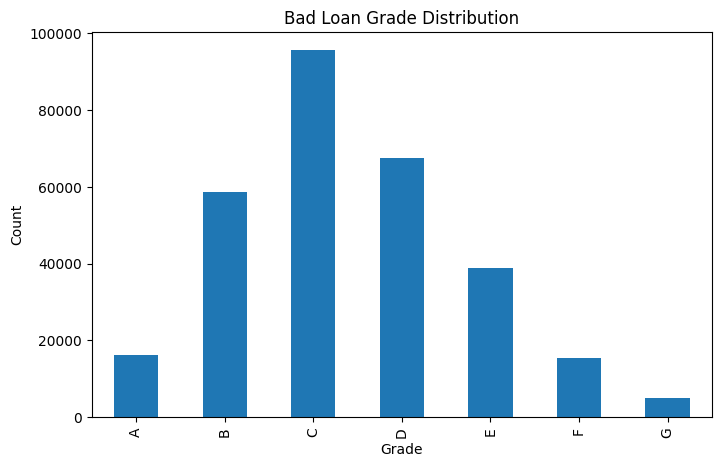

In [152]:
# 불량 대출 등급 분포
plt.figure(figsize=(8,5))
bad_loan_status_to_grades.sort_index().plot(
    kind='bar'
)

plt.title('Bad Loan Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')

plt.show()

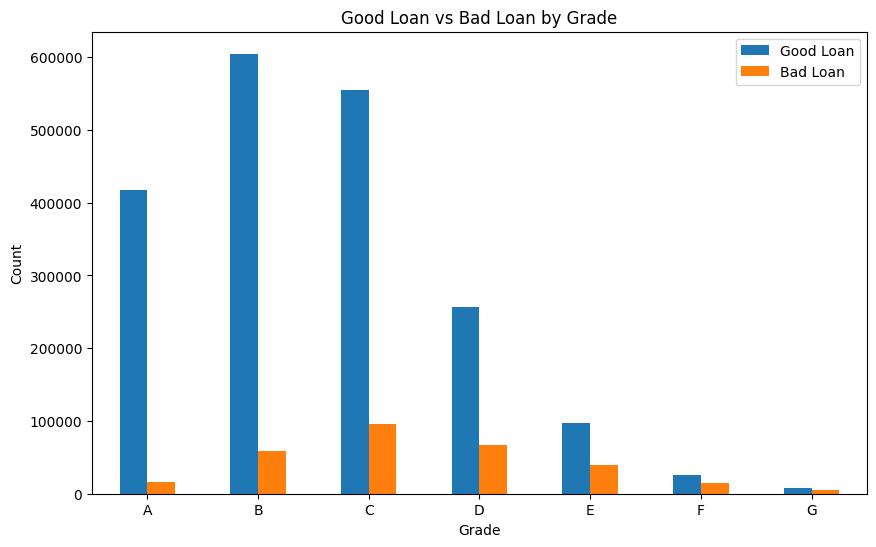

In [153]:
good_grade_counts = good_loan_status_to_grades.sort_index()
bad_grade_counts = bad_loan_status_to_grades.sort_index()

# 두 Series를 하나의 DataFrame으로 결합
compare_df = pd.concat(
    [good_grade_counts, bad_grade_counts],
    axis=1
)

# 컬럼명 지정
compare_df.columns = ['Good Loan','Bad Loan']

# 결측값(NaN)이 있으면 0으로 대체
compare_df = compare_df.fillna(0)

# 시각화
compare_df.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Good Loan vs Bad Loan by Grade')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.xticks(rotation=0)

plt.show()

In [155]:
# 등급별로 우량 상태, 불량상태 비율로 나타내기
grade_status = pd.crosstab(
    df2['grade'],
    df2['bad_loan_status'],
    normalize='index'
)

grade_status

bad_loan_status,False,True
grade,,
A,0.962993,0.037007
B,0.911450,0.088550
C,0.852966,0.147034
D,0.792170,0.207830
E,0.713349,0.286651
F,0.631100,0.368900
G,0.593688,0.406312


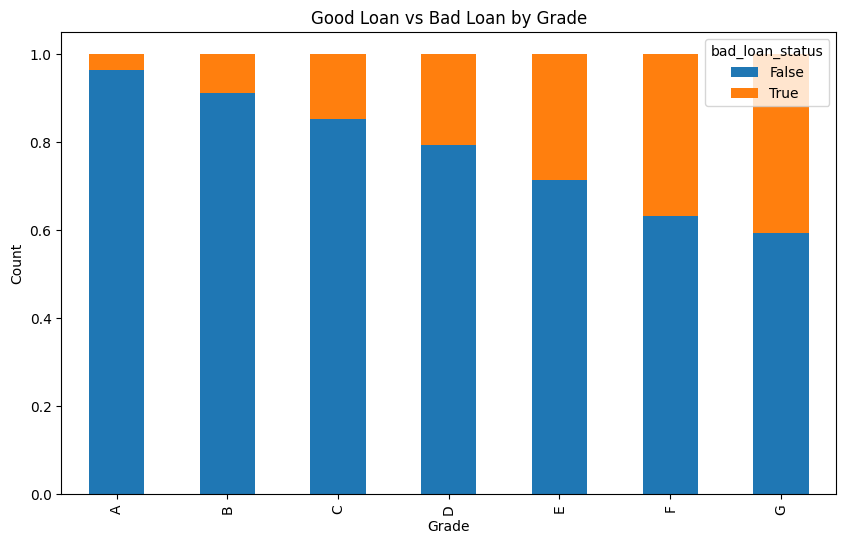

In [156]:
grade_status.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Good Loan vs Bad Loan by Grade')
plt.xlabel('Grade')
plt.ylabel('Count')

plt.show()

## 문제3

In [157]:
df2.head()

,loan_amnt,loan_status,grade,int_rate,term,bad_loan_status
0,2500,Current,C,13.56,36 months,False
1,30000,Current,D,18.94,60 months,False
2,5000,Current,D,17.97,36 months,False
3,4000,Current,D,18.94,36 months,False
4,30000,Current,C,16.14,60 months,False


In [158]:
df2['loan_amnt'].corr(df2['int_rate'])

np.float64(0.09808333533023365)

```
- +1 : 완벽한 양의 상관관계
- 0 : 관계 없음
- -1 : 완벽한 음의 상관관계
```
```
- 0.0 ~ 0.1 : 관계가 거의 없음
- 0.1 ~ 0.3 : 약한 상관관계
- 0.3 ~ 0.5 : 보통 상관관계
- 0.5 ~ 0.7 : 강한 상관관계
- 0.7 ~ 1.0 : 매우 강한 상관관계
```

In [159]:
bad_loan_status_to_grades

grade
C    95580
D    67425
B    58758
E    38881
A    16025
F    15420
G     4944
Name: count, dtype: int64

In [161]:
bad_loan_status_to_grades.sort_index().to_csv('./data/bad_loan_status.csv', sep = ',')